In [8]:
import pandas as pd
import numpy as np 
from sklearn.datasets import make_regression

In [12]:
x,y = make_regression(n_samples=1000,n_targets=1,n_features=2,noise=50,n_informative=2)

In [15]:
df = pd.DataFrame({'feature1':x[:,0],'feature2':x[:,1],'Target':y})

In [16]:
df.head()

,feature1,feature2,Target
0,-1.060421,-0.614178,-87.533534
1,1.444299,0.655262,-12.396345
2,0.303959,0.829007,94.056598
3,1.541059,1.872072,150.026424
4,-3.201129,0.493786,-32.547596


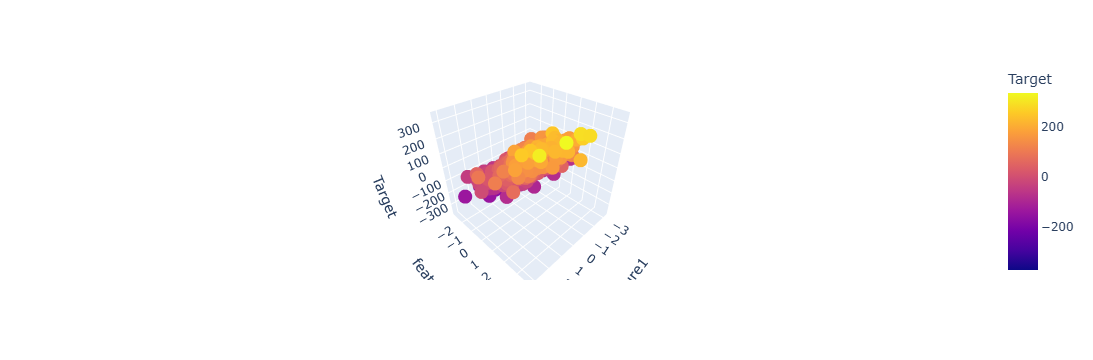

In [20]:
# making a 3d plot
import matplotlib.pyplot as plt
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='feature1',
    y='feature2',
    z='Target',
    color='Target'
)

fig.show()

In [21]:
# now we will apply linear regression 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.iloc[:,0:2],df['Target'],test_size=0.25)

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
lr=LinearRegression()

In [24]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
pred = lr.predict(x_test)

In [26]:
from sklearn.metrics import r2_score
r2_score(y_test,pred)

0.7412264554992691

In [27]:
lr.coef_

array([ 3.50752503, 86.13528561])

In [29]:
lr.intercept_

np.float64(-1.4104057975254294)

C:\Users\singl\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


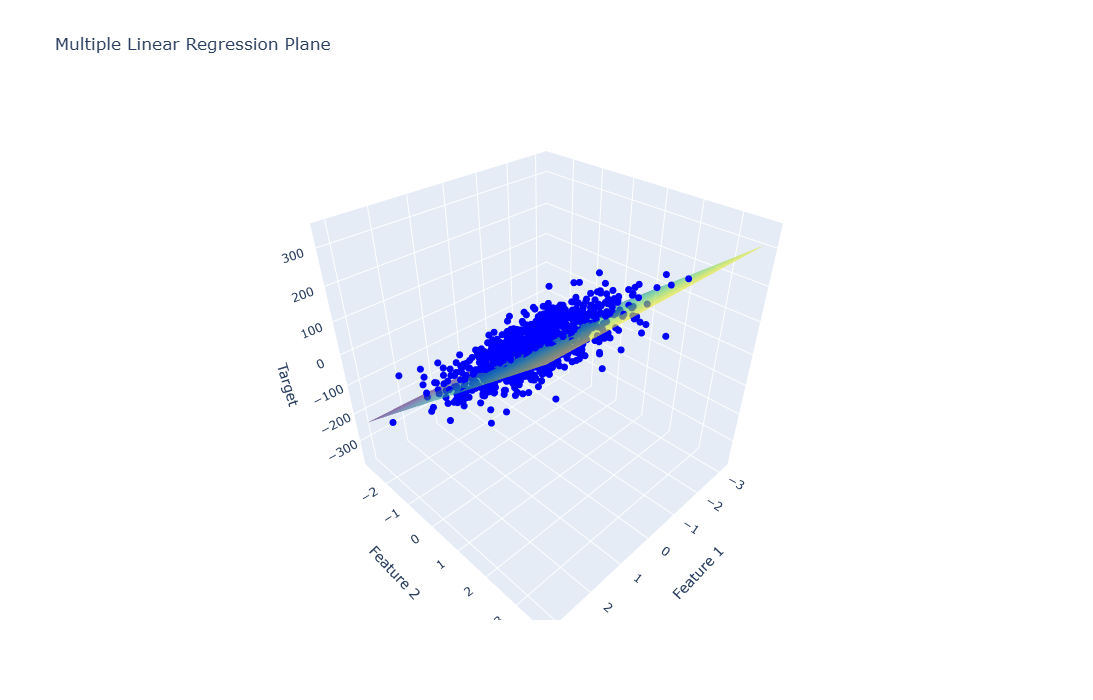

In [32]:
# visualize code copied from chatgpt*
import numpy as np
import plotly.graph_objects as go

# Create grid
x = np.linspace(df['feature1'].min(), df['feature1'].max(), 50)
y = np.linspace(df['feature2'].min(), df['feature2'].max(), 50)

X, Y = np.meshgrid(x, y)

# Predict plane
Z = lr.predict(np.c_[X.ravel(), Y.ravel()])
Z = Z.reshape(X.shape)

fig = go.Figure()

# Scatter points
fig.add_trace(
    go.Scatter3d(
        x=df['feature1'],
        y=df['feature2'],
        z=df['Target'],
        mode='markers',
        marker=dict(size=4, color='blue'),
        name='Data'
    )
)

# Regression plane
fig.add_trace(
    go.Surface(
        x=X,
        y=Y,
        z=Z,
        opacity=0.6,
        colorscale='Viridis',
        showscale=False,
        name='Regression Plane'
    )
)

fig.update_layout(
    title='Multiple Linear Regression Plane',
    scene=dict(
        xaxis_title='Feature 1',
        yaxis_title='Feature 2',
        zaxis_title='Target'
    ),
    width=900,
    height=700
)

fig.show()